In [1]:
# Import basic libraries

import pandas as pd
import numpy as np

# Upload CSV file
from google.colab import files

uploaded = files.upload()

# Read uploaded CSV file
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

# Display first 5 rows
df.head()

Saving AmesHousing.csv to AmesHousing.csv


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [2]:
# Dataset dimensions (rows and columns)

print("Dataset Shape:")
print(df.shape)


# Column names

print("\nColumn Names:")
print(df.columns.tolist())


# Dataset information

print("\nDataset Information:")
df.info()

Dataset Shape:
(2930, 82)

Column Names:
['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 

In [5]:
df.shape




(2930, 82)

In [6]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [8]:
df.isnull().sum().sort_values(ascending=False)

,0
Pool QC,2917
Misc Feature,2824
Alley,2732
Fence,2358
Mas Vnr Type,1775
...,...
Mo Sold,0
Yr Sold,0
Sale Type,0
Sale Condition,0


In [9]:
# Remove columns with excessive missing values

df = df.drop(
    ['Pool QC', 'Misc Feature', 'Alley', 'Fence'],
    axis=1
)

# Check new shape

df.shape

(2930, 78)

In [10]:
# Separate numerical and categorical columns

numeric_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_cols = df.select_dtypes(
    include=['object']
).columns


# Fill numerical missing values with median

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)


# Fill categorical missing values with None

df[categorical_cols] = df[categorical_cols].fillna(
    "None"
)


# Check missing values again

df.isnull().sum().sum()

np.int64(0)

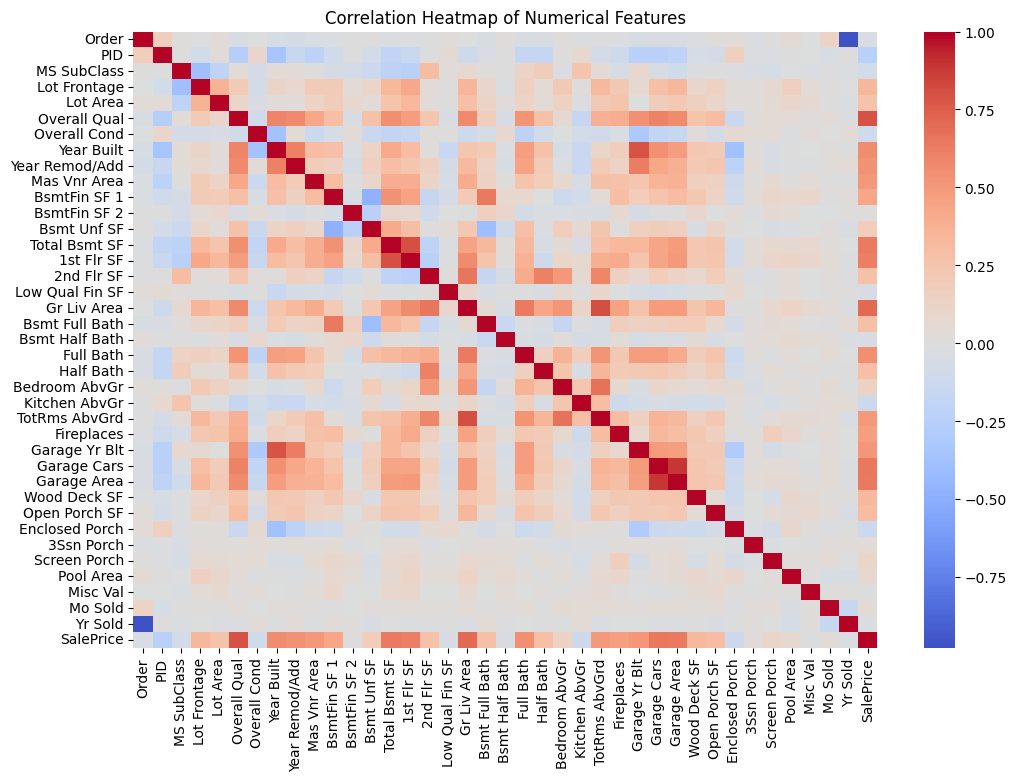

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns only
numeric_df = df.select_dtypes(
    include=['int64', 'float64']
)

# Calculate correlation
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

In [12]:
# Correlation of all numerical features with SalePrice

saleprice_corr = (
    numeric_df.corr()['SalePrice']
    .sort_values(ascending=False)
)

saleprice_corr

,SalePrice
SalePrice,1.000000
Overall Qual,0.799262
Gr Liv Area,0.706780
Garage Cars,0.647812
Garage Area,0.640381
Total Bsmt SF,0.632164
1st Flr SF,0.621676
Year Built,0.558426
Full Bath,0.545604
Year Remod/Add,0.532974


In [13]:
# Define features and target variable

X = df.drop('SalePrice', axis=1)

y = df['SalePrice']


# Check shapes

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2930, 77)
Target shape: (2930,)


In [14]:
from sklearn.model_selection import train_test_split

# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Check shapes

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2344, 77)
X_test: (586, 77)
y_train: (2344,)
y_test: (586,)


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression


# Identify numerical and categorical columns

numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_features = X.select_dtypes(
    include=['object']
).columns


# Preprocessing for numerical data

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)


# Preprocessing for categorical data

categorical_transformer = Pipeline(
    steps=[
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)


# Combine preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


# Create Linear Regression pipeline

linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

print("Pipeline created successfully")

Pipeline created successfully


In [17]:
# Train the Linear Regression model

linear_model.fit(
    X_train,
    y_train
)

print("Linear Regression model trained successfully")

Linear Regression model trained successfully


In [18]:
# Predict house prices

y_pred = linear_model.predict(X_test)


# Show first 10 predictions

y_pred[:10]

array([143756.20884357, 115422.79611729, 169969.11604072, 121490.47535338,
       107728.36044157, 183640.71793622, 134722.5921683 , 169751.86900499,
        68033.1581961 , 306790.77475885])

In [19]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


# Calculate evaluation metrics

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)


# Display results

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Squared Error (MSE): 2112274211.824668
Root Mean Squared Error (RMSE): 45959.48445995307
R² Score: 0.7365436128318209


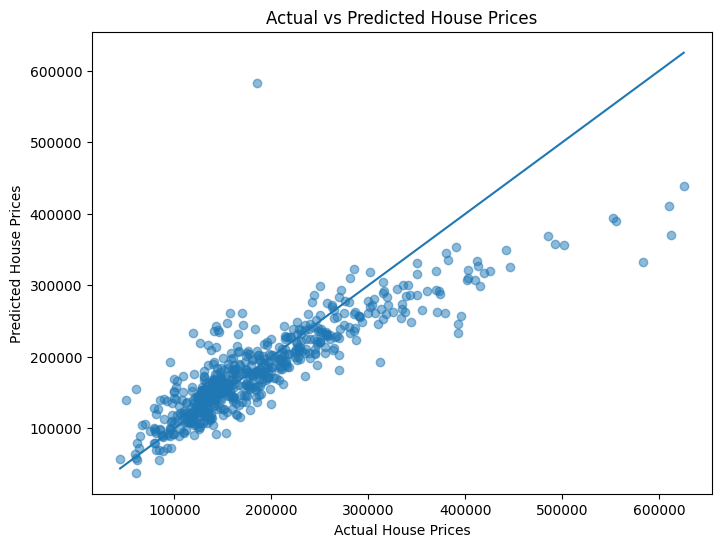

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

# Perfect prediction line

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

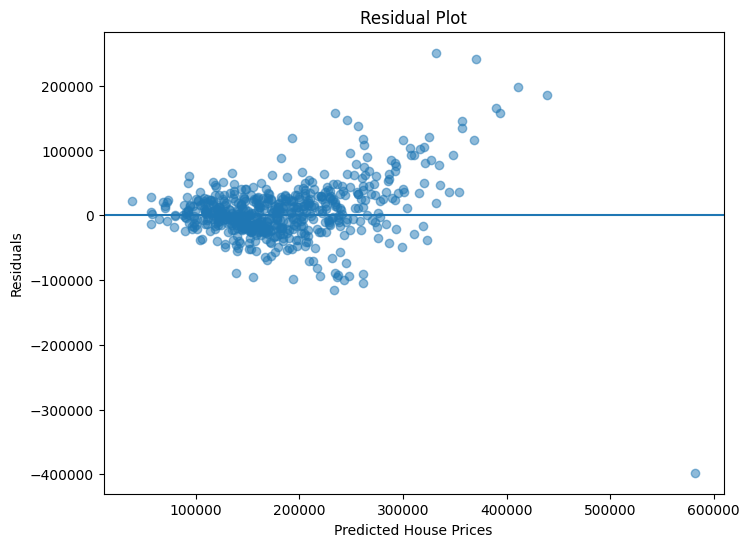

In [21]:
# Calculate residuals

residuals = y_test - y_pred


# Create residual plot

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

# Zero error line

plt.axhline(
    y=0
)

plt.xlabel("Predicted House Prices")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [23]:
# Get trained Linear Regression model

model = linear_model.named_steps['model']


# Get feature names after encoding

feature_names = (
    linear_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)


# Create coefficient dataframe

coef_df = pd.DataFrame(
    {
        'Feature': feature_names,
        'Coefficient': model.coef_
    }
)


# Sort positive impact features

positive_features = coef_df.sort_values(
    by='Coefficient',
    ascending=False
)


positive_features.head(10)

,Feature,Coefficient
17,num__Gr Liv Area,52.813925
13,num__Total Bsmt SF,37.793979
14,num__1st Flr SF,32.638037
10,num__BsmtFin SF 1,27.320235
15,num__2nd Flr SF,20.245886
28,num__Garage Area,19.414871
9,num__Mas Vnr Area,11.857747
12,num__Bsmt Unf SF,10.517829
29,num__Wood Deck SF,6.030017
30,num__Open Porch SF,3.066647


In [24]:
negative_features = coef_df.sort_values(
    by='Coefficient',
    ascending=True
)


negative_features.head(10)

,Feature,Coefficient
35,num__Misc Val,-4.404531
31,num__Enclosed Porch,-1.130707
2,num__MS SubClass,-0.107440
16,num__Low Qual Fin SF,-0.069999
178,cat__Exter Qual_TA,-0.045034
242,cat__Kitchen Qual_TA,-0.041852
195,cat__Bsmt Qual_TA,-0.035701
254,cat__Fireplace Qu_None,-0.033807
11,num__BsmtFin SF 2,-0.033686
185,cat__Foundation_CBlock,-0.032045


In [25]:
from sklearn.linear_model import Ridge


# Create Ridge Regression pipeline

ridge_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', Ridge(alpha=1))
    ]
)


# Train Ridge model

ridge_model.fit(
    X_train,
    y_train
)


print("Ridge Regression model trained successfully")

Ridge Regression model trained successfully


In [26]:
# Ridge predictions

ridge_pred = ridge_model.predict(X_test)


# Ridge metrics

ridge_mse = mean_squared_error(
    y_test,
    ridge_pred
)

ridge_rmse = np.sqrt(ridge_mse)

ridge_r2 = r2_score(
    y_test,
    ridge_pred
)


print("Ridge MSE:", ridge_mse)
print("Ridge RMSE:", ridge_rmse)
print("Ridge R² Score:", ridge_r2)

Ridge MSE: 7512046752.275009
Ridge RMSE: 86672.06442836706
Ridge R² Score: 0.06304934912631288


In [27]:
# Create comparison dataframe

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression"
    ],
    "MSE": [
        mse,
        ridge_mse
    ],
    "RMSE": [
        rmse,
        ridge_rmse
    ],
    "R2 Score": [
        r2,
        ridge_r2
    ]
})


results

,Model,MSE,RMSE,R2 Score
0,Linear Regression,2.112274e+09,45959.484460,0.736544
1,Ridge Regression,7.512047e+09,86672.064428,0.063049


## Model Comparison and Conclusion

The performance of Linear Regression and Ridge Regression models was evaluated using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² score.

The Linear Regression model achieved better performance compared to Ridge Regression, with an R² score of **0.7365** and a lower RMSE value of **45959.48**. This indicates that the model was able to explain approximately **73.65% of the variation in house prices** and provided more accurate predictions on the test dataset.

The coefficient analysis also helped identify the important features that positively or negatively influence house prices. Features with positive coefficients contributed to higher predicted prices, while features with negative coefficients reduced the predicted values.

Based on the evaluation results, **Linear Regression was selected as the best-performing model for house price prediction in this study.**